In [1]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

P0 = -1.185
P1 = -4.211
P2 =  0.007592

MOMENTUM_SMEARING_FRACTION = 0.01
ANGLE_SMEARING_RAD         = 0.004
ANGLE_SMEARING_DEG         = math.degrees(ANGLE_SMEARING_RAD)

Loaded 100000 proton entries
Protons processed   : 100000
Mean delta_p        : 0.046424 GeV/c
Mean p_generated    : 0.6306 GeV/c
Mean p_reconstructed: 0.5842 GeV/c


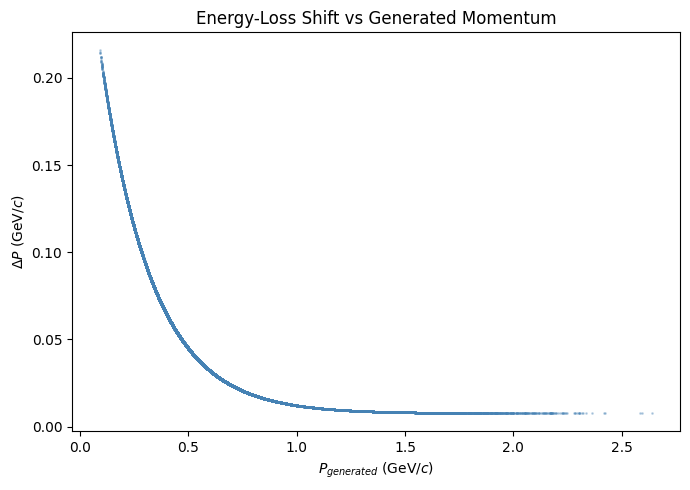

Saved energy_loss_shift.png

Input shape  : (100000, 3)
Target shape : (100000,)

Input means : [5.84198396e-01 3.59201221e-02 3.87072047e+01]
Input stds  : [  0.34353089 103.89500233  16.87540784]

Training samples   : 80000
Validation samples : 20000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 359us/step - loss: 0.0081 - mae: 0.0266 - val_loss: 3.5786e-05 - val_mae: 0.0047
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 312us/step - loss: 2.0689e-05 - mae: 0.0035 - val_loss: 1.4755e-05 - val_mae: 0.0030
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 312us/step - loss: 1.1508e-05 - mae: 0.0026 - val_loss: 7.8580e-06 - val_mae: 0.0022
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 311us/step - loss: 9.6297e-06 - mae: 0.0024 - val_loss: 6.3829e-06 - val_mae: 0.0020
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 311us/step - loss: 1.1603e-05 - mae: 0.0026 - val_loss: 1.4950e-05 - val_mae: 0.0033
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step - loss: 1.0747e-05 - mae: 0.0025 - val_loss: 6.9731e-06 - val_mae: 0.0021
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step - loss: 8.7181e-06 - mae: 0.0022 - val_loss: 1.7462e-05 - val_mae: 0.0033
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step - loss: 1.3006e-05 - mae: 0.00

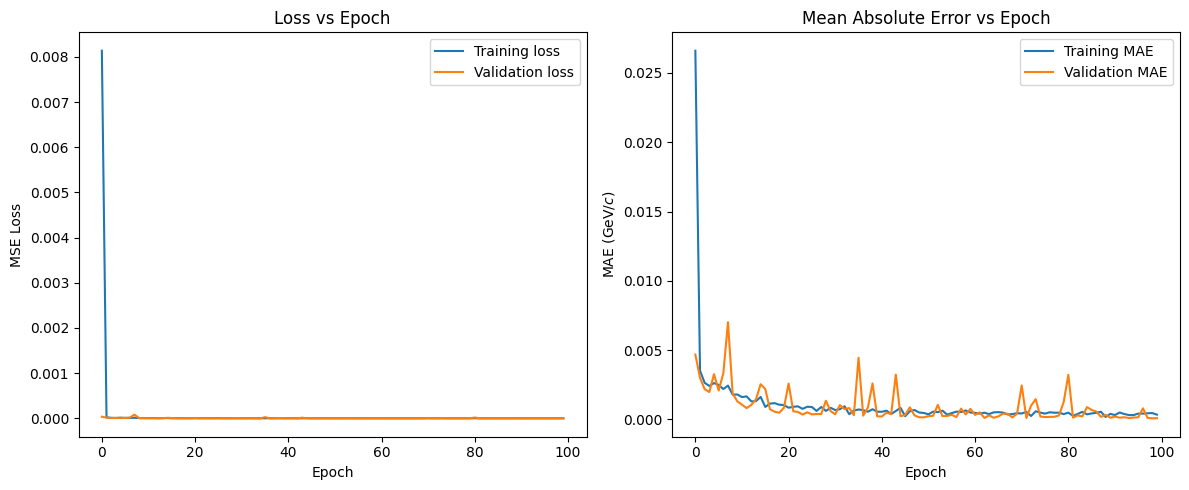

Saved training_history.png
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 151us/step


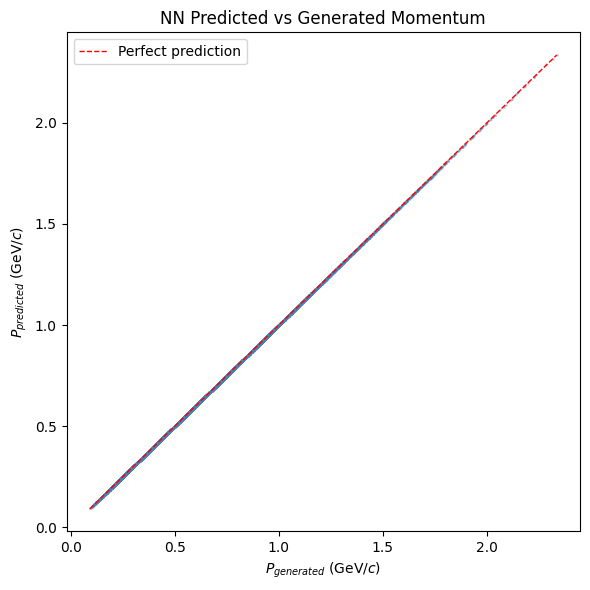

Saved predicted_vs_generated.png


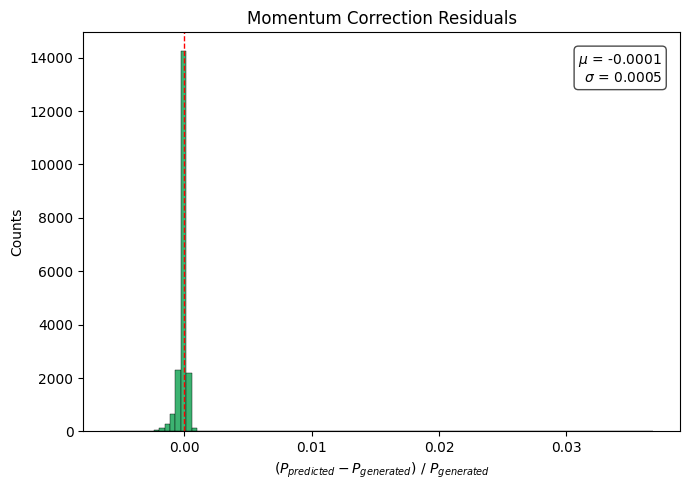

Saved nn_residuals.png


In [2]:
#compute momentum shift
def energy_loss_shift(p_generated):
    delta_p = math.exp(P0 + P1 * p_generated) + P2
    p_reco  = p_generated - delta_p
    return p_reco, delta_p

#apply to all entries
loaded       = np.load('proton_kinematics.npz')
p_gen_proton = list(loaded['p_proton'])
theta_proton = list(loaded['theta_proton'])
phi_proton   = list(loaded['phi_proton'])
weights      = list(loaded['weights'])
print(f"Loaded {len(p_gen_proton)} proton entries")
p_reco_proton = []
delta_p_list  = []

for pg in p_gen_proton:
    pr, dp = energy_loss_shift(pg)
    p_reco_proton.append(pr)
    delta_p_list.append(dp)

print(f"Protons processed   : {len(p_reco_proton)}")
print(f"Mean delta_p        : {np.mean(delta_p_list):.6f} GeV/c")
print(f"Mean p_generated    : {np.mean(p_gen_proton):.4f} GeV/c")
print(f"Mean p_reconstructed: {np.mean(p_reco_proton):.4f} GeV/c")

#quick test: delta_p vs p_generated
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(p_gen_proton, delta_p_list, s=1, alpha=0.3, color='steelblue')
ax.set_xlabel('$P_{generated}$ (GeV/$c$)')
ax.set_ylabel('$\\Delta P$ (GeV/$c$)')
ax.set_title('Energy-Loss Shift vs Generated Momentum')
plt.tight_layout()
plt.savefig('energy_loss_shift.png', dpi=150)
plt.show()
print("Saved energy_loss_shift.png")

#prepare for NN
X = np.column_stack([
    p_reco_proton,
    phi_proton,
    theta_proton,
])
y = np.array(p_gen_proton)
print(f"\nInput shape  : {X.shape}")
print(f"Target shape : {y.shape}")

#generate statistics
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std

#show normalization parameters
print(f"\nInput means : {X_mean}")
print(f"Input stds  : {X_std}")

#80% training, 20% validation, fixed random seed for reproducibility
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")

#begin NN work
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model
model = build_model(input_dim=3)
model.summary()

#NN training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=1,
)

#NN evaluation
#training and validation loss plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history['loss'],     label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].legend()
axes[1].plot(history.history['mae'],     label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (GeV/$c$)')
axes[1].set_title('Mean Absolute Error vs Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("Saved training_history.png")

#predicted vs generated momentum
y_pred = model.predict(X_val).flatten()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, y_pred, s=1, alpha=0.3, color='steelblue')

#perfect prediction line for reference
lims = [min(y_val.min(), y_pred.min()),
        max(y_val.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.0, label='Perfect prediction')
ax.set_xlabel('$P_{generated}$ (GeV/$c$)')
ax.set_ylabel('$P_{predicted}$ (GeV/$c$)')
ax.set_title('NN Predicted vs Generated Momentum')
ax.legend()
plt.tight_layout()
plt.savefig('predicted_vs_generated.png', dpi=150)
plt.show()
print("Saved predicted_vs_generated.png")

#plot residuals
residuals = (y_pred - y_val) / y_val
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=100, color='mediumseagreen',
        edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.0)
ax.set_xlabel('$(P_{predicted} - P_{generated}) \\ / \\ P_{generated}$')
ax.set_ylabel('Counts')
ax.set_title('Momentum Correction Residuals')
mean_res = np.mean(residuals)
std_res  = np.std(residuals)
ax.text(0.97, 0.95, f'$\\mu$ = {mean_res:.4f}\n$\\sigma$ = {std_res:.4f}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('nn_residuals.png', dpi=150)
plt.show()
print("Saved nn_residuals.png")

Protons processed   : 100000
Mean delta_p        : 0.070836 GeV/c
Mean p_generated    : 0.6306 GeV/c
Mean p_reconstructed: 0.5598 GeV/c


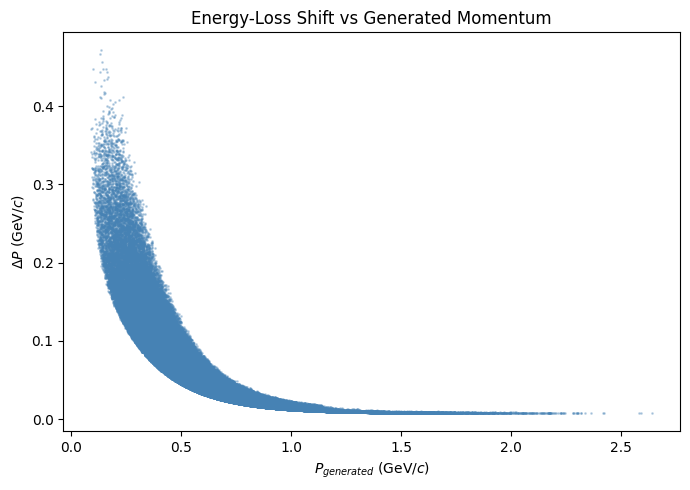

Saved energy_loss_shift_2.png

Input shape  : (100000, 3)
Target shape : (100000,)

Input means : [5.59786377e-01 3.59201221e-02 3.87072047e+01]
Input stds  : [  0.36388797 103.89500233  16.87540784]

Training samples   : 80000
Validation samples : 20000


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 362us/step - loss: 0.0044 - mae: 0.0194 - val_loss: 3.0126e-05 - val_mae: 0.0043
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step - loss: 2.3941e-05 - mae: 0.0038 - val_loss: 1.7119e-05 - val_mae: 0.0033
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 1.5601e-05 - mae: 0.0031 - val_loss: 1.0803e-05 - val_mae: 0.0026
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - loss: 1.5114e-05 - mae: 0.0030 - val_loss: 1.0567e-05 - val_mae: 0.0026
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 1.5443e-05 - mae: 0.0030 - val_loss: 1.1077e-05 - val_mae: 0.0026
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 1.1862e-05 - mae: 0.0026 - val_loss: 1.1753e-05 - val_mae: 0.0027
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 1.1005e-05 - mae: 0.0025 - val_loss: 1.3485e-05 - val_mae: 0.0027
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 1.1828e-05 - mae: 0.00

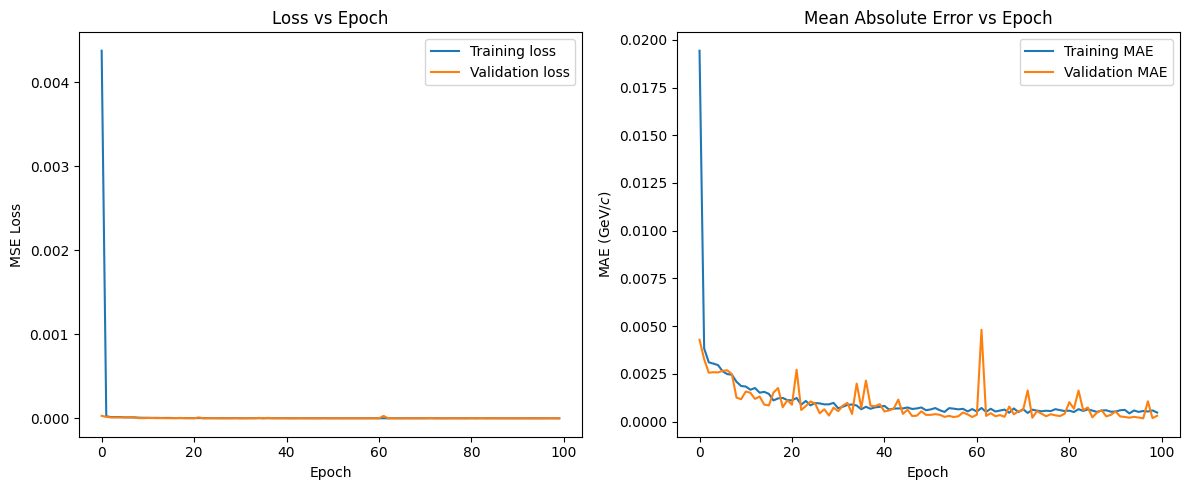

Saved training_history_2.png
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 150us/step


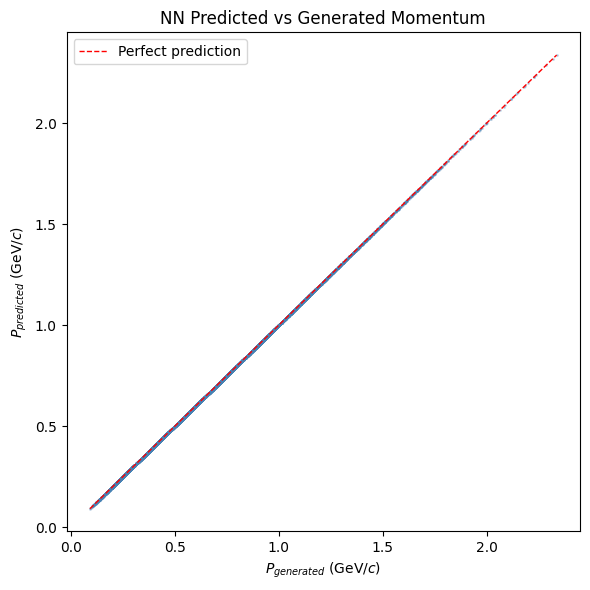

Saved predicted_vs_generated_2.png


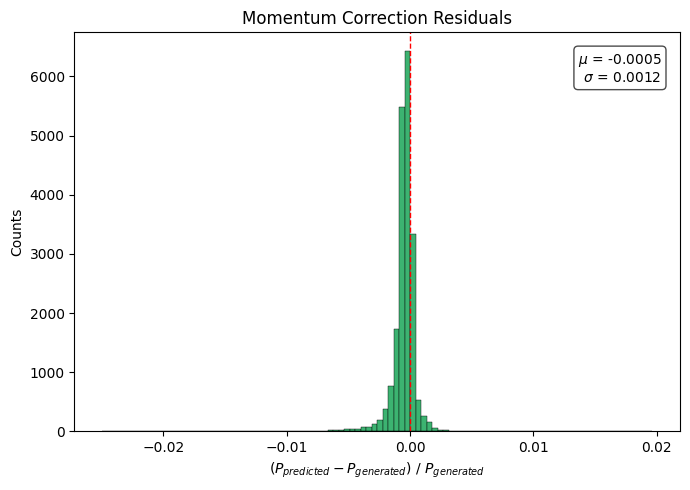

Saved nn_residuals_2.png


In [3]:
#reset lists
p_reco_proton = []
delta_p_list  = []

#compute momentum shift with theta dependence
def energy_loss_shift_theta(p_generated, theta):
    theta_rad = math.radians(theta)
    delta_p = (math.exp(P0 + P1 * p_generated) + P2) * (1 / math.cos(theta_rad))
    p_reco  = p_generated - delta_p
    return p_reco, delta_p

#tie p and theta together and then compute
for pg, th in zip(p_gen_proton, theta_proton):
    pr, dp = energy_loss_shift_theta(pg, th)
    p_reco_proton.append(pr)
    delta_p_list.append(dp)

print(f"Protons processed   : {len(p_reco_proton)}")
print(f"Mean delta_p        : {np.mean(delta_p_list):.6f} GeV/c")
print(f"Mean p_generated    : {np.mean(p_gen_proton):.4f} GeV/c")
print(f"Mean p_reconstructed: {np.mean(p_reco_proton):.4f} GeV/c")

#note: remainder of cell is identical to previous cell aside from png file name
#quick test: delta_p vs p_generated
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(p_gen_proton, delta_p_list, s=1, alpha=0.3, color='steelblue')
ax.set_xlabel('$P_{generated}$ (GeV/$c$)')
ax.set_ylabel('$\\Delta P$ (GeV/$c$)')
ax.set_title('Energy-Loss Shift vs Generated Momentum')
plt.tight_layout()
plt.savefig('energy_loss_shift_2.png', dpi=150)
plt.show()
print("Saved energy_loss_shift_2.png")

#prepare for NN
X = np.column_stack([
    p_reco_proton,
    phi_proton,
    theta_proton,
])
y = np.array(p_gen_proton)
print(f"\nInput shape  : {X.shape}")
print(f"Target shape : {y.shape}")

#generate statistics
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std

#show normalization parameters
print(f"\nInput means : {X_mean}")
print(f"Input stds  : {X_std}")

#80% training, 20% validation, fixed random seed for reproducibility
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")

#begin NN work
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model
model = build_model(input_dim=3)
model.summary()

#NN training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=1,
)

#NN evaluation
#training and validation loss plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history['loss'],     label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].legend()
axes[1].plot(history.history['mae'],     label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (GeV/$c$)')
axes[1].set_title('Mean Absolute Error vs Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig('training_history_2.png', dpi=150)
plt.show()
print("Saved training_history_2.png")

#predicted vs generated momentum
y_pred = model.predict(X_val).flatten()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, y_pred, s=1, alpha=0.3, color='steelblue')

#perfect prediction line for reference
lims = [min(y_val.min(), y_pred.min()),
        max(y_val.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.0, label='Perfect prediction')
ax.set_xlabel('$P_{generated}$ (GeV/$c$)')
ax.set_ylabel('$P_{predicted}$ (GeV/$c$)')
ax.set_title('NN Predicted vs Generated Momentum')
ax.legend()
plt.tight_layout()
plt.savefig('predicted_vs_generated_2.png', dpi=150)
plt.show()
print("Saved predicted_vs_generated_2.png")

#plot residuals
residuals = (y_pred - y_val) / y_val
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=100, color='mediumseagreen',
        edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.0)
ax.set_xlabel('$(P_{predicted} - P_{generated}) \\ / \\ P_{generated}$')
ax.set_ylabel('Counts')
ax.set_title('Momentum Correction Residuals')
mean_res = np.mean(residuals)
std_res  = np.std(residuals)
ax.text(0.97, 0.95, f'$\\mu$ = {mean_res:.4f}\n$\\sigma$ = {std_res:.4f}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('nn_residuals_2.png', dpi=150)
plt.show()
print("Saved nn_residuals_2.png")

Protons processed   : 100000
Mean delta_p        : 0.070836 GeV/c
Mean p_generated    : 0.6306 GeV/c
Mean p_reco         : 0.5598 GeV/c
Mean p_reco_smeared : 0.5598 GeV/c


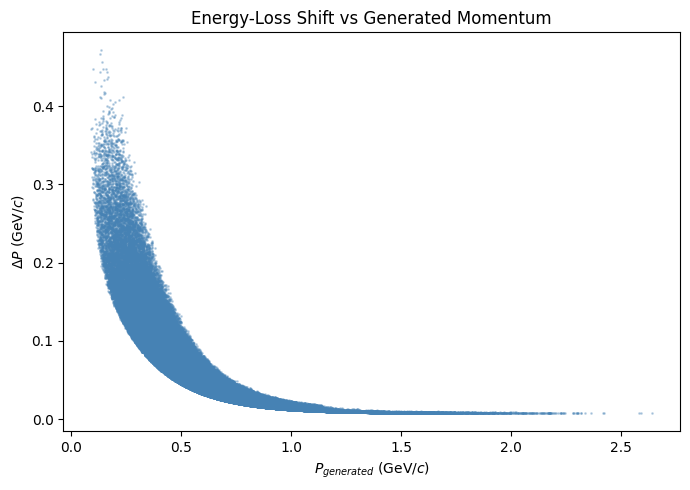

Saved energy_loss_shift_3.png

Input shape  : (100000, 3)
Target shape : (100000,)

Input means : [5.59775656e-01 3.64298974e-02 3.87071529e+01]
Input stds  : [  0.36396673 103.89564693  16.87736492]

Training samples   : 80000
Validation samples : 20000


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 359us/step - loss: 0.0045 - mae: 0.0217 - val_loss: 9.5227e-05 - val_mae: 0.0072
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - loss: 7.4859e-05 - mae: 0.0065 - val_loss: 8.5167e-05 - val_mae: 0.0070
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 7.3177e-05 - mae: 0.0064 - val_loss: 9.9468e-05 - val_mae: 0.0068
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 7.4837e-05 - mae: 0.0064 - val_loss: 1.0264e-04 - val_mae: 0.0081
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - loss: 7.6695e-05 - mae: 0.0065 - val_loss: 9.2814e-05 - val_mae: 0.0073
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 7.3805e-05 - mae: 0.0063 - val_loss: 5.6945e-05 - val_mae: 0.0055
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - loss: 6.7991e-05 - mae: 0.0060 - val_loss: 1.0039e-04 - val_mae: 0.0074
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 6.2547e-05 - mae: 0.00

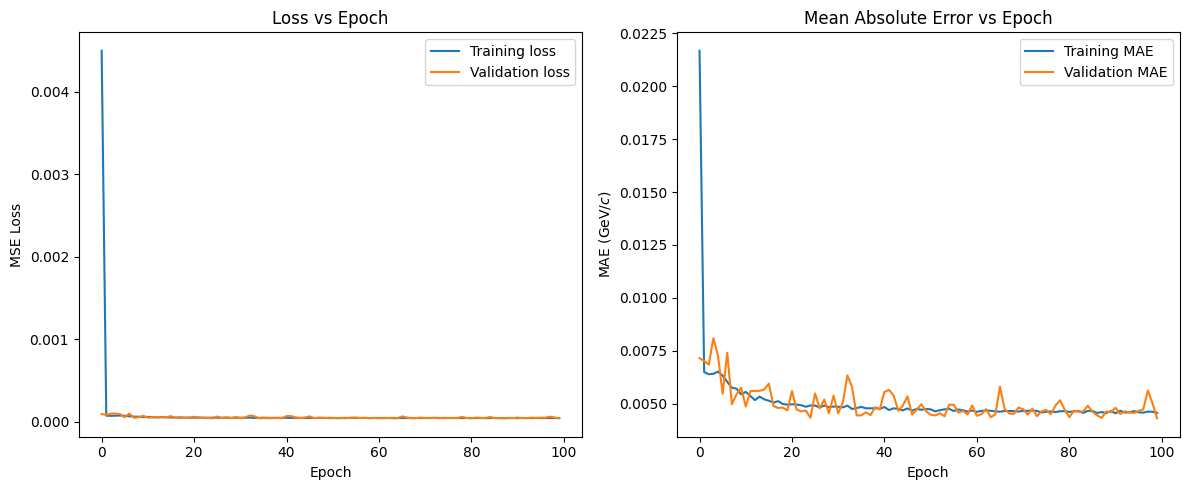

Saved training_history_3.png
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 148us/step


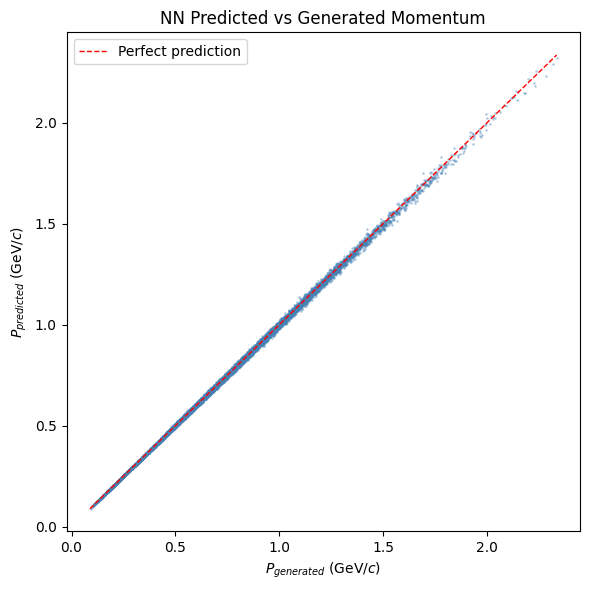

Saved predicted_vs_generated_3.png


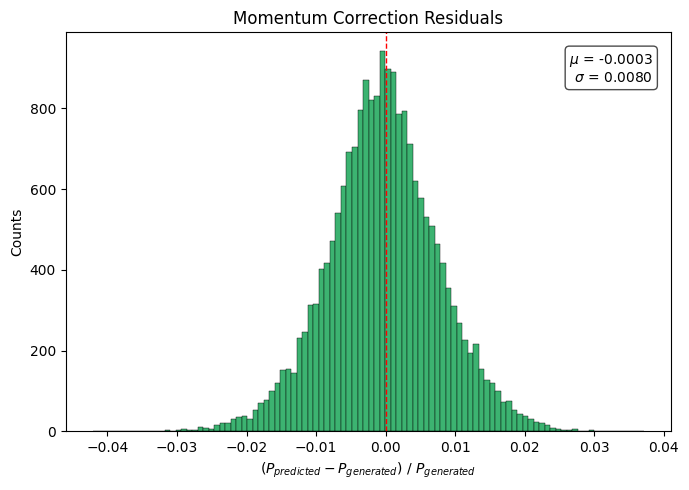

Saved nn_residuals_3.png


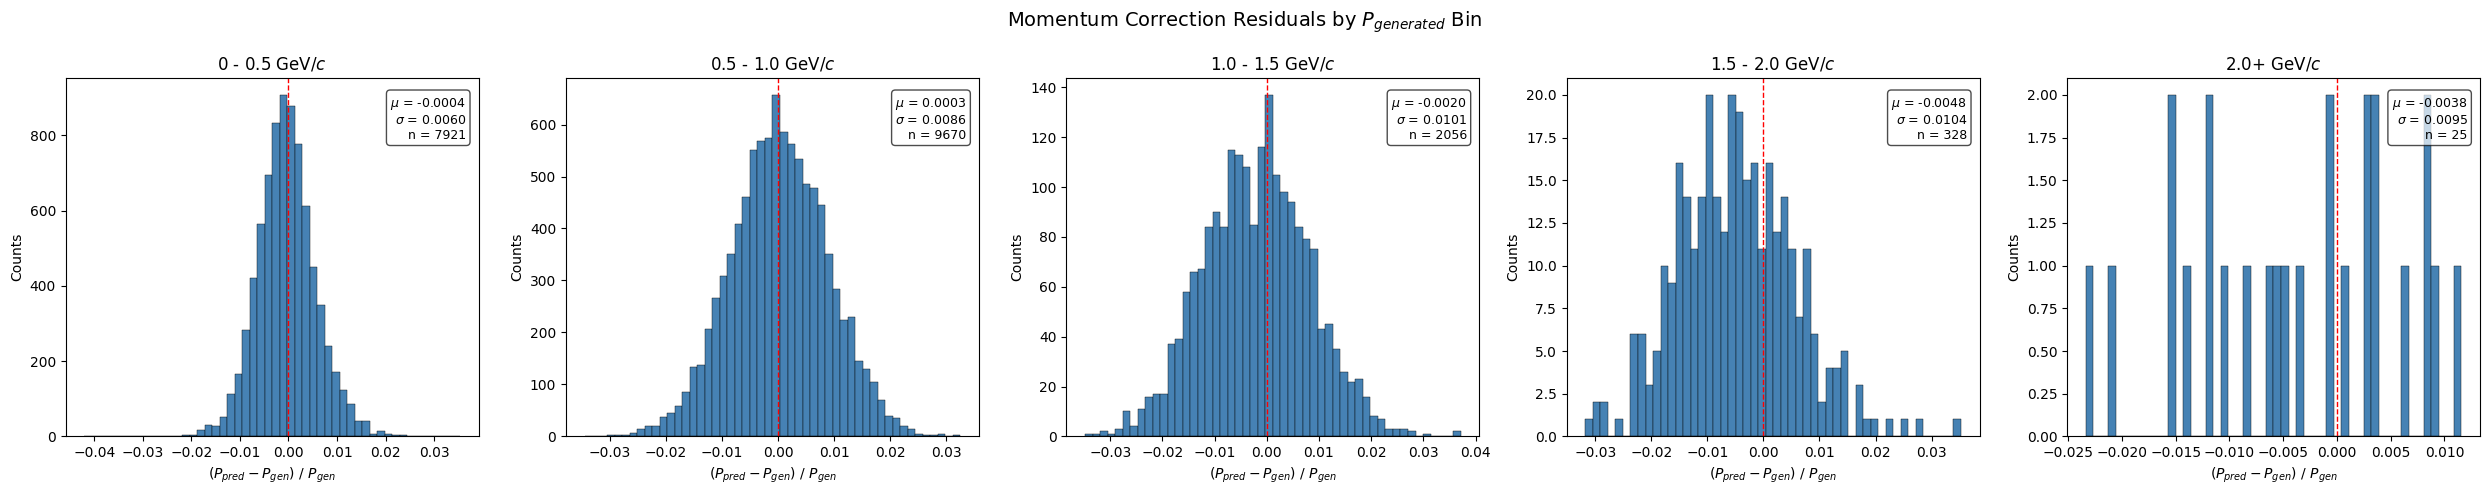

Saved nn_residuals_binned.png


In [4]:
#apply smearing
p_reco_smeared    = [random.gauss(p, MOMENTUM_SMEARING_FRACTION * p)
                     for p in p_reco_proton]
theta_smeared     = [random.gauss(t, ANGLE_SMEARING_DEG)
                     for t in theta_proton]
phi_smeared       = [random.gauss(f, ANGLE_SMEARING_DEG)
                     for f in phi_proton]
print(f"Protons processed   : {len(p_reco_smeared)}")
print(f"Mean delta_p        : {np.mean(delta_p_list):.6f} GeV/c")
print(f"Mean p_generated    : {np.mean(p_gen_proton):.4f} GeV/c")
print(f"Mean p_reco         : {np.mean(p_reco_proton):.4f} GeV/c")
print(f"Mean p_reco_smeared : {np.mean(p_reco_smeared):.4f} GeV/c")

#sanity check again
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(p_gen_proton, delta_p_list, s=1, alpha=0.3, color='steelblue')
ax.set_xlabel('$P_{generated}$ (GeV/$c$)')
ax.set_ylabel('$\\Delta P$ (GeV/$c$)')
ax.set_title('Energy-Loss Shift vs Generated Momentum')
plt.tight_layout()
plt.savefig('energy_loss_shift_3.png', dpi=150)
plt.show()
print("Saved energy_loss_shift_3.png")

#NN prep
X = np.column_stack([
    p_reco_smeared,   # smeared P_reconstructed
    phi_smeared,      # smeared phi
    theta_smeared,    # smeared theta
])
y = np.array(p_gen_proton)
print(f"\nInput shape  : {X.shape}")
print(f"Target shape : {y.shape}")
 
#normalise
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std
print(f"\nInput means : {X_mean}")
print(f"Input stds  : {X_std}")
 
#create training/validating sets
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)
 
#keep track of p for binning
_, _, y_train_pg, y_val_pg = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")

#NN building
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model
 
model = build_model(input_dim=3)
model.summary()
 
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=1,
)

#training and validation loss
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history['loss'],     label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].legend()
axes[1].plot(history.history['mae'],     label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (GeV/$c$)')
axes[1].set_title('Mean Absolute Error vs Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig('training_history_3.png', dpi=150)
plt.show()
print("Saved training_history_3.png")
 
#predicted vs generated
y_pred = model.predict(X_val).flatten()
 
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, y_pred, s=1, alpha=0.3, color='steelblue')
lims = [min(y_val.min(), y_pred.min()),
        max(y_val.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.0, label='Perfect prediction')
ax.set_xlabel('$P_{generated}$ (GeV/$c$)')
ax.set_ylabel('$P_{predicted}$ (GeV/$c$)')
ax.set_title('NN Predicted vs Generated Momentum')
ax.legend()
plt.tight_layout()
plt.savefig('predicted_vs_generated_3.png', dpi=150)
plt.show()
print("Saved predicted_vs_generated_3.png")
 
#total residual plot
residuals = (y_pred - y_val) / y_val
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=100, color='mediumseagreen',
        edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.0)
ax.set_xlabel('$(P_{predicted} - P_{generated}) \\ / \\ P_{generated}$')
ax.set_ylabel('Counts')
ax.set_title('Momentum Correction Residuals')
mean_res = np.mean(residuals)
std_res  = np.std(residuals)
ax.text(0.97, 0.95, f'$\\mu$ = {mean_res:.4f}\n$\\sigma$ = {std_res:.4f}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig('nn_residuals_3.png', dpi=150)
plt.show()
print("Saved nn_residuals_3.png")
 
#binned residual plots
#define momentum bins in GeV/c
bins = [
    (0.0,  0.5,  '0 - 0.5 GeV/$c$'),
    (0.5,  1.0,  '0.5 - 1.0 GeV/$c$'),
    (1.0,  1.5,  '1.0 - 1.5 GeV/$c$'),
    (1.5,  2.0,  '1.5 - 2.0 GeV/$c$'),
    (2.0,  None, '2.0+ GeV/$c$'),
]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Momentum Correction Residuals by $P_{generated}$ Bin', fontsize=14)
for ax, (p_low, p_high, label) in zip(axes, bins):
    #select wanted events
    if p_high is None:
        mask = y_val >= p_low
    else:
        mask = (y_val >= p_low) & (y_val < p_high)
    res_bin = residuals[mask]
    if len(res_bin) == 0:
        ax.set_title(f'{label}\n(no entries)')
        ax.set_xlabel('$(P_{pred} - P_{gen}) / P_{gen}$')
        ax.set_ylabel('Counts')
        continue
    ax.hist(res_bin, bins=50, color='steelblue',
            edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.0)
    ax.set_xlabel('$(P_{pred} - P_{gen}) \\ / \\ P_{gen}$')
    ax.set_ylabel('Counts')
    ax.set_title(label)
    #annotations
    mean_b = np.mean(res_bin)
    std_b  = np.std(res_bin)
    ax.text(0.97, 0.95,
            f'$\\mu$ = {mean_b:.4f}\n$\\sigma$ = {std_b:.4f}\nn = {len(res_bin)}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
 
plt.tight_layout()
plt.savefig('nn_residuals_binned.png', dpi=150)
plt.show()
print("Saved nn_residuals_binned.png")